# 1. Parameter Tuning and Runtime Analysis for mlrose_hiive Problems

This section demonstrates the parameter tuning process for two optimization problems using the `mlrose_hiive` package. In this example, we consider:

1. **Four Peaks Problem (Maximization)**
2. **Flip Flop Problem (Maximization)**

For each problem, three optimization algorithms are applied:
- **Random Hill Climb (RHC)**
- **Simulated Annealing (SA)**
- **Genetic Algorithm (GA)**

The code performs the following steps:
- Sets the random seed for reproducibility.
- Defines the two problems.
- Runs each algorithm with a range of hyperparameters (e.g., RHC restarts, SA initial temperatures, and GA mutation probabilities) to record their fitness curves.
- Plots parameter tuning results (4 subplots per problem: one for each algorithm's tuning and one for the best parameter comparison).
- Records the runtime, initial fitness, final fitness, and the iteration at which the best fitness was achieved for each algorithm.
- Finally, a bar chart comparing the runtime of the best parameter runs for both problems is generated.


In [ ]:
import mlrose_hiive as mlrose
import numpy as np
import matplotlib.pyplot as plt
import math
import time  # Used to record runtime

# Set the random seed for reproducibility
np.random.seed(1024)

# 1. Define the Four Peaks problem (maximization problem)
problem_fp = mlrose.DiscreteOpt(length=20, fitness_fn=mlrose.FourPeaks(), maximize=True, max_val=2)

# 2. Define the Flip Flop problem (maximization problem)
problem_ff = mlrose.DiscreteOpt(length=20, fitness_fn=mlrose.FlipFlop(), maximize=True, max_val=2)

# Set parameters for the optimization algorithms
rhc_restarts_list = [0, 2, 4, 6, 8, 10, 12, 14, 16, 20]  # Refine the search range for RHC restarts
sa_init_temps = [1, 5, 10, 20, 30, 50, 70, 100, 150, 200]  # SA mainly tunes the init_temp parameter
sa_schedule = mlrose.GeomDecay(decay=0.95)  # Choose a stable schedule

ga_mutation_probs = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3, 0.4, 0.5, 0.6]  # Refine the mutation probability range for GA
max_iters = 500  # Fixed maximum number of iterations to ensure a fair comparison

# Record all experimental results
experiment_results = {"Four Peaks": {}, "Flip Flop": {}}

# Run all algorithms on the Four Peaks problem
for restarts in rhc_restarts_list:
    _, best_fitness, fitness_curve_fp = mlrose.random_hill_climb(
        problem_fp, restarts=restarts, curve=True, max_attempts=100, max_iters=max_iters
    )
    experiment_results["Four Peaks"][f"RHC restarts={restarts}"] = np.array(fitness_curve_fp)[:, 0]

for init_temp in sa_init_temps:
    schedule = mlrose.GeomDecay(init_temp=init_temp, decay=0.95)
    _, best_fitness, fitness_curve_fp = mlrose.simulated_annealing(
        problem_fp, schedule=schedule, curve=True, max_attempts=100, max_iters=max_iters
    )
    experiment_results["Four Peaks"][f"SA init_temp={init_temp}"] = np.array(fitness_curve_fp)[:, 0]

for mutation_prob in ga_mutation_probs:
    _, best_fitness, fitness_curve_fp = mlrose.genetic_alg(
        problem_fp, mutation_prob=mutation_prob, curve=True, max_attempts=100, max_iters=max_iters
    )
    experiment_results["Four Peaks"][f"GA mutation_prob={mutation_prob}"] = np.array(fitness_curve_fp)[:, 0]

# Run all algorithms on the Flip Flop problem (parameters are the same as above)
for restarts in rhc_restarts_list:
    _, best_fitness, fitness_curve_ff = mlrose.random_hill_climb(
        problem_ff, restarts=restarts, curve=True, max_attempts=100, max_iters=max_iters
    )
    experiment_results["Flip Flop"][f"RHC restarts={restarts}"] = np.array(fitness_curve_ff)[:, 0]

for init_temp in sa_init_temps:
    schedule = mlrose.GeomDecay(init_temp=init_temp, decay=0.95)
    _, best_fitness, fitness_curve_ff = mlrose.simulated_annealing(
        problem_ff, schedule=schedule, curve=True, max_attempts=100, max_iters=max_iters
    )
    experiment_results["Flip Flop"][f"SA init_temp={init_temp}"] = np.array(fitness_curve_ff)[:, 0]

for mutation_prob in ga_mutation_probs:
    _, best_fitness, fitness_curve_ff = mlrose.genetic_alg(
        problem_ff, mutation_prob=mutation_prob, curve=True, max_attempts=100, max_iters=max_iters
    )
    experiment_results["Flip Flop"][f"GA mutation_prob={mutation_prob}"] = np.array(fitness_curve_ff)[:, 0]

# Plot the first set of figures: Parameter tuning results (4 subplots per problem, unified x-axis range)
for problem, results in experiment_results.items():
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = np.ravel(axes)
    
    # Set a unified Y-axis scale
    max_fitness_val = max([max(values) for values in results.values() if len(values) > 0]) * 1.05
    
    # RHC parameter comparison
    rhc_keys = [key for key in results.keys() if "RHC" in key]
    for key in rhc_keys:
        axes[0].plot(results[key], label=key)
    axes[0].set_title(f"{problem} - RHC Parameter Tuning")
    axes[0].set_ylim(0, max_fitness_val)
    axes[0].set_ylabel("Fitness")
    axes[0].set_xlim(0, max_iters)  # Unified x-axis range
    axes[0].legend()
    
    # SA parameter comparison
    sa_keys = [key for key in results.keys() if "SA" in key]
    for key in sa_keys:
        axes[1].plot(results[key], label=key)
    axes[1].set_title(f"{problem} - SA Parameter Tuning")
    axes[1].set_ylim(0, max_fitness_val)
    axes[1].set_ylabel("Fitness")
    axes[1].set_xlim(0, max_iters)  # Unified x-axis range
    axes[1].legend()
    
    # GA parameter comparison
    ga_keys = [key for key in results.keys() if "GA" in key]
    for key in ga_keys:
        axes[2].plot(results[key], label=key)
    axes[2].set_title(f"{problem} - GA Parameter Tuning")
    axes[2].set_ylim(0, max_fitness_val)
    axes[2].set_ylabel("Fitness")
    axes[2].set_xlim(0, max_iters)  # Unified x-axis range
    axes[2].legend()
    
    # Best parameter comparison
    best_rhc = max(rhc_keys, key=lambda k: max(results[k]))
    best_sa = max(sa_keys, key=lambda k: max(results[k]))
    best_ga = max(ga_keys, key=lambda k: max(results[k]))
    
    axes[3].plot(results[best_rhc], label=best_rhc)
    axes[3].plot(results[best_sa], label=best_sa)
    axes[3].plot(results[best_ga], label=best_ga)
    axes[3].set_title(f"{problem} - Best Parameter Comparison")
    axes[3].set_ylim(0, max_fitness_val)
    axes[3].set_ylabel("Fitness")
    axes[3].set_xlim(0, max_iters)  # Unified x-axis range
    axes[3].legend()
    
    plt.tight_layout()
    plt.savefig(f"{problem.replace(' ', '_')}_parameter_tuning.png")
    plt.show()

#############################################
# Record the runtime, initial fitness, final fitness, and the iteration at which the best fitness was achieved
#############################################

# Save detailed information for the best parameter runs for each problem
best_run_info = {"Four Peaks": {}, "Flip Flop": {}}

# For each problem, re-run the best parameter settings for the three algorithms (RHC, SA, GA) and record timing
for problem_name in ["Four Peaks", "Flip Flop"]:
    problem_instance = problem_fp if problem_name == "Four Peaks" else problem_ff

    results = experiment_results[problem_name]
    # Extract all parameter settings for each algorithm
    rhc_keys = [key for key in results.keys() if "RHC" in key]
    sa_keys = [key for key in results.keys() if "SA" in key]
    ga_keys = [key for key in results.keys() if "GA" in key]

    # Find the best parameter setting for each algorithm (based on the highest fitness in the curve)
    best_rhc_key = max(rhc_keys, key=lambda k: max(results[k]))
    best_sa_key = max(sa_keys, key=lambda k: max(results[k]))
    best_ga_key = max(ga_keys, key=lambda k: max(results[k]))

    # RHC best parameter run and timing
    restarts_val = int(best_rhc_key.split('=')[1])
    t_start = time.time()
    best_state, best_fitness, fitness_curve = mlrose.random_hill_climb(
        problem_instance, restarts=restarts_val, curve=True,
        max_attempts=100, max_iters=max_iters
    )
    t_elapsed = time.time() - t_start
    initial_fitness = fitness_curve[0, 0] if len(fitness_curve) > 0 else None
    # Record the iteration at which the maximum fitness was achieved
    best_iter = int(np.argmax(fitness_curve[:, 0]))
    best_run_info[problem_name]["RHC"] = {
        "initial_fitness": initial_fitness,
        "final_fitness": best_fitness,
        "best_iteration": best_iter,
        "time": t_elapsed
    }

    # SA best parameter run and timing
    init_temp_val = float(best_sa_key.split('=')[1])
    schedule = mlrose.GeomDecay(init_temp=init_temp_val, decay=0.95)
    t_start = time.time()
    best_state, best_fitness, fitness_curve = mlrose.simulated_annealing(
        problem_instance, schedule=schedule, curve=True,
        max_attempts=100, max_iters=max_iters
    )
    t_elapsed = time.time() - t_start
    initial_fitness = fitness_curve[0, 0] if len(fitness_curve) > 0 else None
    best_iter = int(np.argmax(fitness_curve[:, 0]))
    best_run_info[problem_name]["SA"] = {
        "initial_fitness": initial_fitness,
        "final_fitness": best_fitness,
        "best_iteration": best_iter,
        "time": t_elapsed
    }

    # GA best parameter run and timing
    mutation_prob_val = float(best_ga_key.split('=')[1])
    t_start = time.time()
    best_state, best_fitness, fitness_curve = mlrose.genetic_alg(
        problem_instance, mutation_prob=mutation_prob_val, curve=True,
        max_attempts=100, max_iters=max_iters
    )
    t_elapsed = time.time() - t_start
    initial_fitness = fitness_curve[0, 0] if len(fitness_curve) > 0 else None
    best_iter = int(np.argmax(fitness_curve[:, 0]))
    best_run_info[problem_name]["GA"] = {
        "initial_fitness": initial_fitness,
        "final_fitness": best_fitness,
        "best_iteration": best_iter,
        "time": t_elapsed
    }

    # Print the results
    print(f"Problem: {problem_name}")
    for alg in ["RHC", "SA", "GA"]:
        info = best_run_info[problem_name][alg]
        print(f"  {alg}: Initial Fitness = {info['initial_fitness']}, "
              f"Final Fitness = {info['final_fitness']}, "
              f"Best Iteration = {info['best_iteration']}, "
              f"Training Time = {info['time']:.4f} seconds")

#############################################
# Plot the final runtime bar chart (one plot with 6 bars: three for Four Peaks and three for Flip Flop)
#############################################

algorithms = ["RHC", "SA", "GA"]
times_fp = [best_run_info["Four Peaks"][alg]["time"] for alg in algorithms]
times_ff = [best_run_info["Flip Flop"][alg]["time"] for alg in algorithms]

# Width of each group of bars
bar_width = 0.1
# Two groups corresponding to the two problems
group_positions = np.arange(2)

fig, ax = plt.subplots(figsize=(10, 6))

# Set offsets for each algorithm's bars within each group
offsets = [-bar_width, 0, bar_width]
for i, alg in enumerate(algorithms):
    # The corresponding runtime data for each group: [Four Peaks, Flip Flop]
    times = [times_fp[i], times_ff[i]]
    ax.bar(group_positions + offsets[i], times, width=bar_width, label=alg)

ax.set_xticks(group_positions)
ax.set_xticklabels(['Four Peaks', 'Flip Flop'])
ax.set_ylabel("Time (seconds)")
ax.set_title("Training Time for Best Parameter Runs")
ax.legend()
plt.savefig("mlrose_problems_runtime_bar_chart.png")
plt.show()


# 2. DNN Training with Backpropagation and Randomized Optimization on the Spotify Dataset

In this section, we focus on training a Deep Neural Network (DNN) for a classification task using the Spotify dataset. The work is divided into several key components:

- **Data Preparation and Model Definition**:  
  The dataset is loaded and preprocessed using PyTorch which was used in assignment 1. A DNN model is defined with three hidden layers and configurable activation functions (e.g., tanh, ReLU, or sigmoid),same as assignment 1.

- **Backpropagation Training**:  
  The network is trained using standard backpropagation with an Adam optimizer. During training, both the training and testing error curves are recorded, and the overall training time is measured.

- **Randomized Optimization (RO) Tuning with mlrose_hiive**:  
  The training data is converted to NumPy arrays for compatibility with mlrose_hiive. Multiple RO algorithms are then applied:
  - Random Hill Climb (RHC)
  - Simulated Annealing (SA)
  - Genetic Algorithm (GA)
  - Gradient Descent (GD) as a baseline  
  For each algorithm, hyperparameters such as the number of restarts (for RHC), initial temperature (for SA), and mutation probability (for GA) are tuned over a fixed number of iterations. Each run records the fitness/error curve, the iteration at which the best performance is achieved, and the training duration.

- **Visualization and Analysis**:  
  The results are visualized using:
  - A set of 6 subplots that display:
    - The fitness curves for each RO algorithm,
    - The DNN training error curve (via backpropagation),
    - A comparison of the best-performing RO settings.
    - The comparision of trained model evaluation (accuracy) on testset.
  - A bar chart that compares the training times across all methods (RHC, SA, GA, GD, and standard DNN training).

Backprop (DNN) training time on Spotify: 3.49 s
DNN (Backprop) Train Error: start=0.1509, final=0.0709
DNN (Backprop) Test Error: start=0.1623, final=0.0838
Gradient Descent training time on Spotify: 0.44 s

Best RHC Result:
  RHC restarts=5:
    Starting Fitness: 1.4845
    Final Fitness: 1.4842
    Best Iteration: 49
    Training Time: 1.26 s
    Test Error: 0.5216

Best SA Result:
  SA init_temp=1:
    Starting Fitness: 1.4846
    Final Fitness: 1.4845
    Best Iteration: 23
    Training Time: 0.26 s
    Test Error: 0.5216

Best GA Result:
  GA mut_prob=0.01:
    Starting Fitness: 4.3272
    Final Fitness: 2.5205
    Best Iteration: 35
    Training Time: 32.30 s
    Test Error: 0.3921

Gradient Descent Result:
  Starting Fitness: 1.4845
  Final Fitness: 0.0239
  Best Iteration: 49
  Training Time: 0.44 s
  Test Error: 0.3575


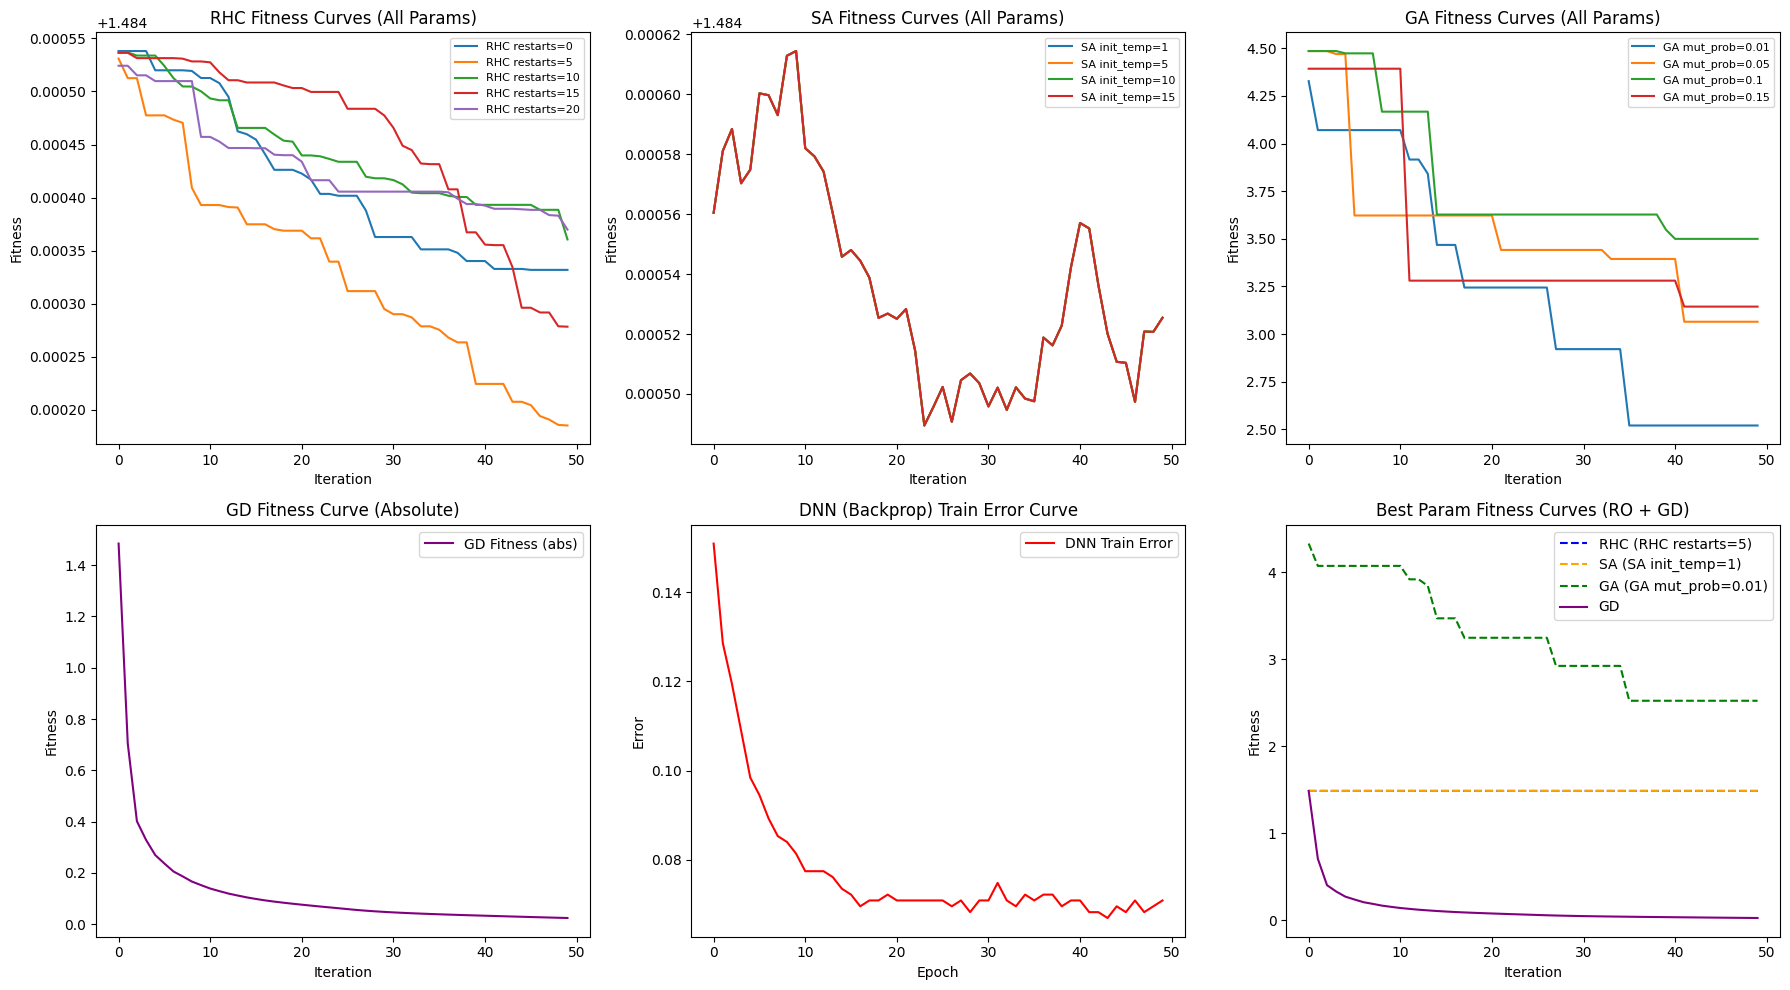


Test Accuracies:
  RHC: 0.4784
  SA: 0.4784
  GA: 0.6079
  GD: 0.6425
  DNN (Backprop): 0.9162


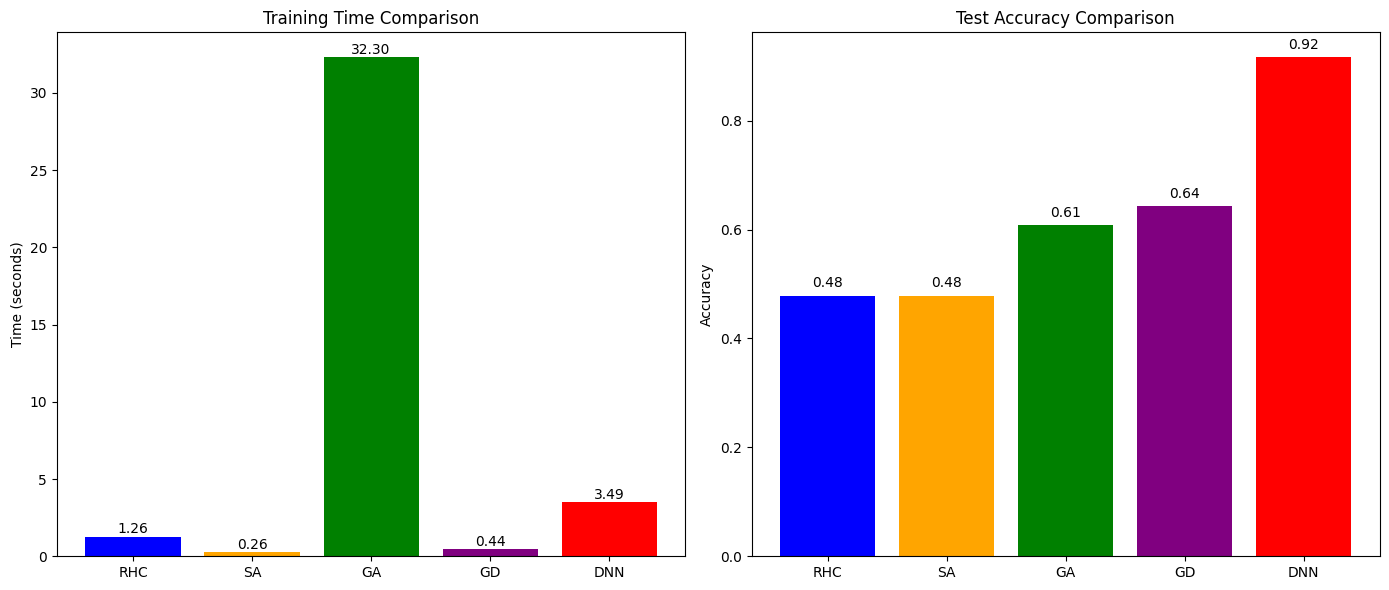

In [1]:
import os
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
import random
import numpy as np
import time
import mlrose_hiive as mlrose

# ===============================
# 1) Set up random seed
# ===============================
def set_seed(seed=1024):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
set_seed(1024)

# ===============================
# 2) Load Spotify Dataset
# ===============================
train_df = pd.read_csv("train_processed.csv")
test_df = pd.read_csv("test_processed.csv")
X_train = torch.tensor(train_df.drop(columns=['popularity']).values, dtype=torch.float32)
y_train = torch.tensor(train_df['popularity'].values, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(test_df.drop(columns=['popularity']).values, dtype=torch.float32)
y_test = torch.tensor(test_df['popularity'].values, dtype=torch.float32).unsqueeze(1)

# ===============================
# 3) Define the DNN Model (Backprop)
# ===============================
class DNN(nn.Module):
    def __init__(self, input_size, activation='relu'):
        super(DNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, 64)
        self.output = nn.Linear(64, 1)
        activations = {'relu': nn.ReLU(), 'tanh': nn.Tanh(), 'sigmoid': nn.Sigmoid()}
        self.activation = activations.get(activation, nn.ReLU())
        self.sigmoid = nn.Sigmoid()
        self.dropout = nn.Dropout(0.5)
        
    def forward(self, x):
        x = self.activation(self.fc1(x))
        x = self.dropout(x)
        x = self.activation(self.fc2(x))
        x = self.dropout(x)
        x = self.activation(self.fc3(x))
        x = self.sigmoid(self.output(x))
        return x

# ===============================
# 4) Backprop training (A1 style)
# ===============================
def train_model(activation, lr=0.001, epochs=50, 
                X_train=None, y_train=None, 
                X_test=None, y_test=None):
    """Returns (train_error_curve, test_error_curve)."""
    train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
    model = DNN(input_size=X_train.shape[1], activation=activation)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    
    train_errors, test_errors = [], []
    for epoch in range(epochs):
        model.train()
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
        model.eval()
        with torch.no_grad():
            train_preds = (model(X_train) >= 0.5).float()
            test_preds  = (model(X_test)  >= 0.5).float()
            train_error = 1 - (train_preds.eq(y_train).sum() / len(y_train)).item()
            test_error  = 1 - (test_preds.eq(y_test).sum() / len(y_test)).item()
        train_errors.append(train_error)
        test_errors.append(test_error)
    return train_errors, test_errors

# ===============================
# 5) Train DNN (Backprop) on Spotify
# ===============================
best_activation = 'tanh'
best_lr = 0.001
epochs_bp = 50

start_sp = time.time()
bp_train_sp, bp_test_sp = train_model(best_activation, best_lr, epochs=epochs_bp,
                                      X_train=X_train, y_train=y_train,
                                      X_test=X_test,  y_test=y_test)
time_sp = time.time() - start_sp

print(f"Backprop (DNN) training time on Spotify: {time_sp:.2f} s")
print(f"DNN (Backprop) Train Error: start={bp_train_sp[0]:.4f}, final={bp_train_sp[-1]:.4f}")
print(f"DNN (Backprop) Test Error: start={bp_test_sp[0]:.4f}, final={bp_test_sp[-1]:.4f}")

# ===============================
# 6) Convert data to NumPy for RO
# ===============================
X_train_np = X_train.numpy()
y_train_np = (y_train.numpy().ravel() > 0.5).astype(int)
X_test_np  = X_test.numpy()
y_test_np  = (y_test.numpy().ravel() > 0.5).astype(int)

# ===============================
# 7) train_nn_ro: run continuous 50 iterations in one fit call
# ===============================
def train_nn_ro(algorithm, X_train, y_train, X_test, y_test, max_iters=50, lr=0.001, **kwargs):
    """
    Train a neural network using mlrose.NeuralNetwork with the given RO algorithm.
    Returns: (nn_model, fitness_curve, best_iter, best_error, duration)
    If fitness_curve is 2D, we take the first column as the fitness.
    """
    if algorithm == 'gradient_descent':
        extra = {}
    elif algorithm == 'random_hill_climb':
        extra = {'restarts': kwargs.get('restarts', 0)}
    elif algorithm == 'simulated_annealing':
        schedule = mlrose.GeomDecay(init_temp=kwargs.get('init_temp', 10), decay=0.95)
        extra = {'schedule': schedule}
    elif algorithm == 'genetic_alg':
        extra = {'mutation_prob': kwargs.get('mutation_prob', 0.1), 'pop_size': 200}
    else:
        extra = {}
        
    nn_model = mlrose.NeuralNetwork(
        hidden_nodes=[64,64,64],
        activation='tanh',
        algorithm=algorithm,
        max_iters=max_iters,
        bias=True,
        is_classifier=True,
        learning_rate=lr,
        early_stopping=True,
        clip_max=5,
        max_attempts=50,
        random_state=1024,
        curve=True,
        **extra
    )
    start_time = time.time()
    nn_model.fit(X_train, y_train)
    duration = time.time() - start_time
    fc = np.array(nn_model.fitness_curve)
    if fc.ndim == 2:
        fitness_curve = fc[:,0]
    else:
        fitness_curve = fc
    # For GD, take absolute value
    if algorithm == 'gradient_descent':
        fitness_curve = np.abs(fitness_curve)
    best_iter = int(np.argmin(fitness_curve))
    best_error = fitness_curve[best_iter]
    return nn_model, fitness_curve, best_iter, best_error, duration

# ===============================
# 8) Hyperparameter tuning for RO on Spotify
# ===============================
rhc_restarts_list = [0, 5, 10, 15, 20]
sa_init_temps = [1, 5, 10, 15]
ga_mutation_probs = [0.01, 0.05, 0.1, 0.15]
max_iters_ro = 50

def tune_rhc(X_train, y_train, X_test, y_test, hyperparams, max_iters=50):
    results = {}
    for r in hyperparams:
        model, curve, best_iter, best_err, dur = train_nn_ro(
            'random_hill_climb', X_train, y_train, X_test, y_test,
            max_iters=max_iters, lr=best_lr, restarts=r)
        results[f"RHC restarts={r}"] = (model, curve, best_iter, best_err, dur)
    return results

def tune_sa(X_train, y_train, X_test, y_test, hyperparams, max_iters=50):
    results = {}
    for t in hyperparams:
        model, curve, best_iter, best_err, dur = train_nn_ro(
            'simulated_annealing', X_train, y_train, X_test, y_test,
            max_iters=max_iters, lr=best_lr, init_temp=t)
        results[f"SA init_temp={t}"] = (model, curve, best_iter, best_err, dur)
    return results

def tune_ga(X_train, y_train, X_test, y_test, hyperparams, max_iters=50):
    results = {}
    for m in hyperparams:
        model, curve, best_iter, best_err, dur = train_nn_ro(
            'genetic_alg', X_train, y_train, X_test, y_test,
            max_iters=max_iters, lr=best_lr, mutation_prob=m)
        results[f"GA mut_prob={m}"] = (model, curve, best_iter, best_err, dur)
    return results

# Run tuning for RO algorithms
rhc_results_spotify = tune_rhc(X_train_np, y_train_np, X_test_np, y_test_np, rhc_restarts_list, max_iters=max_iters_ro)
sa_results_spotify  = tune_sa(X_train_np, y_train_np, X_test_np, y_test_np, sa_init_temps,     max_iters=max_iters_ro)
ga_results_spotify  = tune_ga(X_train_np, y_train_np, X_test_np, y_test_np, ga_mutation_probs, max_iters=max_iters_ro)

# Train GD (without tuning)
nn_model_gd, fitness_gd, best_iter_gd, best_err_gd, dur_gd = train_nn_ro(
    'gradient_descent', X_train_np, y_train_np, X_test_np, y_test_np,
    max_iters=max_iters_ro, lr=best_lr)
print(f"Gradient Descent training time on Spotify: {dur_gd:.2f} s")

# -------------------------
# 8.1) Compute and print detailed info for best hyperparameter settings (RO algorithms)
def compute_test_error(model, X_test, y_test):
    preds = model.predict(X_test)
    return 1 - np.mean(preds == y_test)

# For RHC
best_rhc_key = min(rhc_results_spotify, key=lambda x: rhc_results_spotify[x][3])
model_rhc, curve_rhc, best_iter_rhc, best_err_rhc, dur_rhc = rhc_results_spotify[best_rhc_key]
test_error_rhc = compute_test_error(model_rhc, X_test_np, y_test_np)
print("\nBest RHC Result:")
print(f"  {best_rhc_key}:")
print(f"    Starting Fitness: {curve_rhc[0]:.4f}")
print(f"    Final Fitness: {curve_rhc[-1]:.4f}")
print(f"    Best Iteration: {best_iter_rhc}")
print(f"    Training Time: {dur_rhc:.2f} s")
print(f"    Test Error: {test_error_rhc:.4f}")

# For SA
best_sa_key = min(sa_results_spotify, key=lambda x: sa_results_spotify[x][3])
model_sa, curve_sa, best_iter_sa, best_err_sa, dur_sa = sa_results_spotify[best_sa_key]
test_error_sa = compute_test_error(model_sa, X_test_np, y_test_np)
print("\nBest SA Result:")
print(f"  {best_sa_key}:")
print(f"    Starting Fitness: {curve_sa[0]:.4f}")
print(f"    Final Fitness: {curve_sa[-1]:.4f}")
print(f"    Best Iteration: {best_iter_sa}")
print(f"    Training Time: {dur_sa:.2f} s")
print(f"    Test Error: {test_error_sa:.4f}")

# For GA
best_ga_key = min(ga_results_spotify, key=lambda x: ga_results_spotify[x][3])
model_ga, curve_ga, best_iter_ga, best_err_ga, dur_ga = ga_results_spotify[best_ga_key]
test_error_ga = compute_test_error(model_ga, X_test_np, y_test_np)
print("\nBest GA Result:")
print(f"  {best_ga_key}:")
print(f"    Starting Fitness: {curve_ga[0]:.4f}")
print(f"    Final Fitness: {curve_ga[-1]:.4f}")
print(f"    Best Iteration: {best_iter_ga}")
print(f"    Training Time: {dur_ga:.2f} s")
print(f"    Test Error: {test_error_ga:.4f}")

# For Gradient Descent
test_error_gd = compute_test_error(nn_model_gd, X_test_np, y_test_np)
print("\nGradient Descent Result:")
print(f"  Starting Fitness: {fitness_gd[0]:.4f}")
print(f"  Final Fitness: {fitness_gd[-1]:.4f}")
print(f"  Best Iteration: {best_iter_gd}")
print(f"  Training Time: {dur_gd:.2f} s")
print(f"  Test Error: {test_error_gd:.4f}")

# -------------------------
# 9) First Composite Figure: 6 subplots
fig1, axes1 = plt.subplots(2, 3, figsize=(18, 10))
axes1 = axes1.ravel()

# (0,0): RHC fitness curves (all parameters)
for key, (_, curve, _, _, _) in rhc_results_spotify.items():
    axes1[0].plot(range(len(curve)), curve, label=key, linewidth=1.5)
axes1[0].set_title("RHC Fitness Curves (All Params)")
axes1[0].set_xlabel("Iteration")
axes1[0].set_ylabel("Fitness")
axes1[0].legend(fontsize=8)

# (0,1): SA fitness curves (all parameters)
for key, (_, curve, _, _, _) in sa_results_spotify.items():
    axes1[1].plot(range(len(curve)), curve, label=key, linewidth=1.5)
axes1[1].set_title("SA Fitness Curves (All Params)")
axes1[1].set_xlabel("Iteration")
axes1[1].set_ylabel("Fitness")
axes1[1].legend(fontsize=8)

# (0,2): GA fitness curves (all parameters)
for key, (_, curve, _, _, _) in ga_results_spotify.items():
    axes1[2].plot(range(len(curve)), curve, label=key, linewidth=1.5)
axes1[2].set_title("GA Fitness Curves (All Params)")
axes1[2].set_xlabel("Iteration")
axes1[2].set_ylabel("Fitness")
axes1[2].legend(fontsize=8)

# (1,0): GD fitness curve (absolute value)
axes1[3].plot(range(len(fitness_gd)), fitness_gd, label="GD Fitness (abs)", color='purple', linewidth=1.5)
axes1[3].set_title("GD Fitness Curve (Absolute)")
axes1[3].set_xlabel("Iteration")
axes1[3].set_ylabel("Fitness")
axes1[3].legend()

# (1,1): DNN (Backprop) Train Error Curve
axes1[4].plot(range(len(bp_train_sp)), bp_train_sp, label="DNN Train Error", color='red', linewidth=1.5)
axes1[4].set_title("DNN (Backprop) Train Error Curve")
axes1[4].set_xlabel("Epoch")
axes1[4].set_ylabel("Error")
axes1[4].legend()

# (1,2): Best parameter fitness curves for RO + GD
_, best_rhc_curve, _, _, _ = rhc_results_spotify[best_rhc_key]
_, best_sa_curve, _, _, _ = sa_results_spotify[best_sa_key]
_, best_ga_curve, _, _, _ = ga_results_spotify[best_ga_key]
axes1[5].plot(range(len(best_rhc_curve)), best_rhc_curve, linestyle='--', label=f"RHC ({best_rhc_key})", color='blue', linewidth=1.5)
axes1[5].plot(range(len(best_sa_curve)), best_sa_curve, linestyle='--', label=f"SA ({best_sa_key})", color='orange', linewidth=1.5)
axes1[5].plot(range(len(best_ga_curve)), best_ga_curve, linestyle='--', label=f"GA ({best_ga_key})", color='green', linewidth=1.5)
axes1[5].plot(range(len(fitness_gd)), fitness_gd, linestyle='-', label="GD", color='purple', linewidth=1.5)
axes1[5].set_title("Best Param Fitness Curves (RO + GD)")
axes1[5].set_xlabel("Iteration")
axes1[5].set_ylabel("Fitness")
axes1[5].legend()

plt.tight_layout()
plt.savefig("Spotify dataset training.png")
plt.show()

# -------------------------

def compute_accuracy(model, X_test, y_test):
    preds = model.predict(X_test)
    return np.mean(preds == y_test)

acc_rhc = compute_accuracy(model_rhc, X_test_np, y_test_np)
acc_sa  = compute_accuracy(model_sa, X_test_np, y_test_np)
acc_ga  = compute_accuracy(model_ga, X_test_np, y_test_np)
acc_gd  = compute_accuracy(nn_model_gd, X_test_np, y_test_np)
acc_dnn = 1 - bp_test_sp[-1]

print(f"\nTest Accuracies:")
print(f"  RHC: {acc_rhc:.4f}")
print(f"  SA: {acc_sa:.4f}")
print(f"  GA: {acc_ga:.4f}")
print(f"  GD: {acc_gd:.4f}")
print(f"  DNN (Backprop): {acc_dnn:.4f}")

# 10) Second Composite Figure: 2 subplots
fig2, axes2 = plt.subplots(1, 2, figsize=(14, 6))

# (0,0): Bar chart for training time (RHC, SA, GA, GD, DNN)
def get_best_time(res_dict):
    best_key = min(res_dict, key=lambda x: res_dict[x][3])
    return res_dict[best_key][4]

best_rhc_time = get_best_time(rhc_results_spotify)
best_sa_time  = get_best_time(sa_results_spotify)
best_ga_time  = get_best_time(ga_results_spotify)
gd_time_val   = dur_gd
dnn_time_val  = time_sp

methods = ["RHC", "SA", "GA", "GD", "DNN"]
times = [best_rhc_time, best_sa_time, best_ga_time, gd_time_val, dnn_time_val]

axes2[0].bar(methods, times, color=["blue", "orange", "green", "purple", "red"])
axes2[0].set_title("Training Time Comparison")
axes2[0].set_ylabel("Time (seconds)")
for i, t_val in enumerate(times):
    axes2[0].text(i, t_val + 0.02, f"{t_val:.2f}", ha='center', va='bottom', fontsize=10)

# (0,1): Bar chart for final test accuracy (RHC, SA, GA, GD, DNN)
accuracies = [acc_rhc, acc_sa, acc_ga, acc_gd, acc_dnn]
axes2[1].bar(methods, accuracies, color=["blue", "orange", "green", "purple", "red"])
axes2[1].set_title("Test Accuracy Comparison")
axes2[1].set_ylabel("Accuracy")
for i, acc in enumerate(accuracies):
    axes2[1].text(i, acc + 0.01, f"{acc:.2f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig("Time and accuracy.png")
plt.show()
